# Runbook: fractional differentiation, stationarity versus memory (SYNTHETIC data)

> **The committed outputs of this notebook are computed on SYNTHETIC data.** The five symbols
> `SYN_A` to `SYN_E` come from the committed sample read by `openquant.data.fetch` (seeded
> log-normal random walks, see `DATA_SOURCES.md`), and the control series are simulated below with
> a known order of integration. Nothing here describes a real market. Read the results as *what the
> method does on data whose properties are known*.

AFML Chapter 5 (§5.4-5.6, Snippets 5.1-5.4) argues that the choice between a price level
(memory, no stationarity) and returns (stationarity, no memory) is a false binary: differencing a
series a fractional $d<1$ times can pass a unit-root test while still tracking the level. This
runbook runs the procedure behind AFML Fig. 5.5 per series, checks it against series whose answer
is known, and decides whether $d^*$ should become the default feature transform in later runbooks.

**Run it on your own data.** The parameters cell reads three environment variables, so the
notebook runs unchanged on any OHLCV file `openquant.data` can load. Write the executed copy and
its figures outside the repository, so nothing computed on your data is committed:

```bash
OPENQUANT_RUNBOOK_SOURCE=/path/to/daily_ohlcv.parquet \
OPENQUANT_RUNBOOK_SYMBOLS=ES,NQ,CL \
OPENQUANT_RUNBOOK_RANGE=2015-01-01:2024-12-31 \
OPENQUANT_FIGURE_DIR=/tmp/fracdiff-figures \
  uv run --python .venv/bin/python python notebooks/python/scripts/execute_notebook_cells.py \
    notebooks/python/09_fracdiff_stationarity_memory.ipynb --out /tmp/09_on_my_data.ipynb
```

The file needs a `symbol` column and the columns `clean_ohlcv` recognises (`date`/`ts`, `close`,
...). For a vendor API, set `SOURCE` in the parameters cell to a `CallableSource` around your own
fetch function; `fetch` caches the result on your machine. The control simulations do not depend
on the data source.

Sections follow the research-notebook contract (#46): Setup, Hypothesis, Data, Method, Results,
Analysis, Promotion decision, Self-review, Reproducibility.

## Setup

In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from importlib.metadata import version

import nbfigures
import numpy as np
import openquant
import polars as pl
from openquant import fracdiff

# ---- parameters (fixed before the first run) ---------------------------------------------------
SEED = 49  # control simulations; the SYN_* sample has its own fixed seed
D_GRID = [round(0.05 * i, 2) for i in range(21)]  # 0.00, 0.05, ..., 1.00
FFD_THRESH = 1e-3  # FFD weight floor (Snippet 5.3); AFML's Snippet 5.4 uses 1e-2
ADF_LAGS = 1  # Snippet 5.4: adfuller(maxlag=1, regression="c", autolag=None)
ALPHA = "5%"  # stationary if the ADF statistic is below the 5% critical value
MIN_MEMORY = 0.5  # "high correlation" means corr(FFD at d*, log price) >= 0.5
DELTAS = (0.4, 0.7, 1.0)  # integration orders of the control simulations
N_REPS = 200  # control paths per delta
N_CONTROL = 520  # control path length = the sample's length (two years of daily bars)
SENS_LAGS = 5  # sensitivity only: the control study repeated with 5 lagged differences

# ---- data source --------------------------------------------------------------------------------
# Default: the committed SYNTHETIC sample (no network). Override with the env vars below, or set
# SOURCE to any openquant.data DataSource (e.g. a CallableSource around your vendor's API).
_src_env = os.environ.get("OPENQUANT_RUNBOOK_SOURCE", "").strip()
SOURCE = openquant.data.LocalFileSource(_src_env, name="user-file") if _src_env else None
SYMBOLS = os.environ.get("OPENQUANT_RUNBOOK_SYMBOLS", "SYN_A,SYN_B,SYN_C,SYN_D,SYN_E").split(",")
START, END = os.environ.get("OPENQUANT_RUNBOOK_RANGE", "2022-01-03:2023-12-29").split(":")
SYNTHETIC = SOURCE is None
LABEL = "SYNTHETIC" if SYNTHETIC else "user data"

print(f"d grid: {len(D_GRID)} values from {D_GRID[0]} to {D_GRID[-1]}; FFD thresh {FFD_THRESH}")
print(f"source: {'committed SYNTHETIC sample' if SYNTHETIC else 'user file'}; symbols: {SYMBOLS}")

d grid: 21 values from 0.0 to 1.0; FFD thresh 0.001
source: committed SYNTHETIC sample; symbols: ['SYN_A', 'SYN_B', 'SYN_C', 'SYN_D', 'SYN_E']


## Hypothesis

**H1.** For each series there is a minimum $d^* < 1$ on the grid at which the fixed-width-window
fractionally differenced (FFD) log price rejects a unit root (ADF, constant, one lag, 5%), and at
that $d^*$ the FFD series keeps a correlation of at least **0.5** with the original log price
(AFML Fig. 5.5 analogue).

Pre-registered before running:

- H1 is **supported for a series** if $d^* < 1$ **and** $\rho(d^*) \ge 0.5$; **rejected** otherwise.
- The promotion question (use $d^*$ as the default feature transform in later runbooks) is decided
  by whether H1 holds on the sample symbols, whether $d^*$ is stable between the two halves of the
  sample, and whether the procedure recovers the known answer on the controls.

What theory predicts on data with known properties: a fractionally integrated series of order
$\delta$, differenced $d$ times, is integrated of order $\delta-d$ and is (covariance-)stationary
only once $\delta - d < 0.5$. So the population answer is $d^* \approx \max(0,\ \delta - 0.5)$.
The `SYN_*` symbols are log-normal random walks ($\delta = 1$), so theory puts their $d^*$ at
about 0.5. The controls pin the procedure down at $\delta = 0.4$ (already stationary), $0.7$ and
$1.0$.

## Data

In [2]:
bars, meta = openquant.data.fetch(SYMBOLS, START, END, source=SOURCE, return_meta=True)
print("source:", meta["source"], f"| {LABEL}" + (", not market data" if SYNTHETIC else ""))
print("rows:", meta["rows"], "| dataset_hash:", meta["dataset_hash"])

log_close = {
    sym: np.log(bars.filter(pl.col("symbol") == sym).sort("ts")["close"].to_numpy())
    for sym in SYMBOLS
}
pl.DataFrame(
    {
        "symbol": SYMBOLS,
        "bars": [len(log_close[s]) for s in SYMBOLS],
        "first": [str(bars.filter(pl.col("symbol") == s)["ts"].min().date()) for s in SYMBOLS],
        "last": [str(bars.filter(pl.col("symbol") == s)["ts"].max().date()) for s in SYMBOLS],
    }
)

source: openquant-synthetic-sample | SYNTHETIC, not market data
rows: 2600 | dataset_hash: sha256:b311c219efb2a19db449767cc8600139c030aad15496b011fc650b4880550eea


symbol,bars,first,last
str,i64,str,str
"""SYN_A""",520,"""2022-01-03""","""2023-12-29"""
"""SYN_B""",520,"""2022-01-03""","""2023-12-29"""
"""SYN_C""",520,"""2022-01-03""","""2023-12-29"""
"""SYN_D""",520,"""2022-01-03""","""2023-12-29"""
"""SYN_E""",520,"""2022-01-03""","""2023-12-29"""


**Controls with a known order of integration.** The `SYN_*` sample contains only random walks,
so on its own it cannot show whether the sweep finds the *right* $d^*$, or a different one when
the memory is different. The controls are simulated here as type-II fractionally integrated noise,
$x_t = \sum_{k=0}^{t} \psi_k \varepsilon_{t-k}$ with $\psi_0 = 1$ and
$\psi_k = \psi_{k-1}(k-1+\delta)/k$ (for $\delta=1$ every $\psi_k=1$: a random walk), scaled to a
log price with 1% daily volatility, 520 bars like the sample.

They are a Monte Carlo of 200 paths per $\delta$, sharing the same seeded innovations across
$\delta$. A first draft of this notebook used one 2,000-bar path per $\delta$; its $\delta=1$
path rejected a unit root already at $d=0$, which is what a 5% test does one time in twenty, and a
single path cannot tell that apart from a property of the method. The replications can.

controls: delta in (0.4, 0.7, 1.0), 200 paths x 520 bars each

controls dataset_hash: sha256:e7c5f3a944e21bab352c8c434957c9491ca7f60ca8538a9b155816f262afe34f


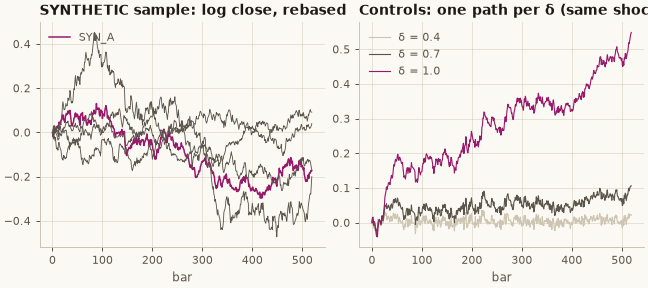

In [3]:
def fractionally_integrated(delta: float, eps: np.ndarray) -> np.ndarray:
    # Type-II FI(delta) paths from innovations eps (reps x n).
    n = eps.shape[-1]
    psi = np.ones(n)
    for k in range(1, n):
        psi[k] = psi[k - 1] * (k - 1 + delta) / k
    return np.stack([np.convolve(e, psi)[:n] for e in np.atleast_2d(eps)])


eps = np.random.default_rng(SEED).standard_normal((N_REPS, N_CONTROL))
controls = {delta: np.log(100.0) + 0.01 * fractionally_integrated(delta, eps) for delta in DELTAS}
controls_hash = openquant.data.dataset_hash(
    pl.DataFrame({f"delta_{d}": controls[d].ravel() for d in DELTAS})
)
print(f"controls: delta in {DELTAS}, {N_REPS} paths x {N_CONTROL} bars each")
# The hash covers float bits that differ in the last place between platforms (libm, SIMD),
# so it goes to stderr, which the staleness check ignores; every number derived from the
# controls is still checked.
print("controls dataset_hash:", controls_hash, file=sys.stderr)


def draw(fig, c):
    left, right = fig.subplots(1, 2, sharey=False)
    for i, sym in enumerate(SYMBOLS):
        first = i == 0
        left.plot(log_close[sym] - log_close[sym][0], color=c["accent"] if first else c["muted"],
                  linewidth=1.2 if first else 0.7, label=sym if first else None)
    left.set_title(f"{LABEL} sample: log close, rebased")
    left.set_xlabel("bar")
    left.legend(loc="upper left")
    for delta, col in zip(DELTAS, [c["rule"], c["muted"], c["accent"]]):
        path = controls[delta][0]
        right.plot(path - path[0], color=col, linewidth=0.9, label=f"δ = {delta}")
    right.set_title("Controls: one path per δ (same shocks)")
    right.set_xlabel("bar")
    right.legend(loc="upper left")


nbfigures.figure(
    "nb09-inputs",
    draw,
    alt="Left: rebased log closes of the five synthetic sample symbols. Right: one simulated control path for each integration order 0.4, 0.7 and 1.0, driven by the same shocks.",
)

## Method

For every series and every $d$ in the grid (21 values, 0 to 1 in steps of 0.05):

1. **FFD.** `openquant.fracdiff.frac_diff_ffd(log_price, d, thresh=1e-3)` (Snippet 5.3). Each
   output is a fixed linear combination of the current and past `width - 1` values; the first
   `width - 1` outputs are `NaN` and are dropped. $d=0$ is the log price itself; $d=1$ is the log
   return. The table also reports `weight_sum`, the sum of the truncated weights: an untruncated
   $(1-B)^d$ has weights summing to 0 for any $d>0$, and whatever the truncation leaves over is
   the share of the *level* that passes straight through to the output.
2. **ADF.** Augmented Dickey-Fuller regression with a constant and one lagged difference,
   $\Delta y_t = \alpha + \gamma y_{t-1} + \phi \Delta y_{t-1} + e_t$, statistic
   $t_\gamma$, as in Snippet 5.4 (`adfuller(maxlag=1, regression="c", autolag=None)`).
   `statsmodels` is not a dependency of this repository, so the regression is written below in
   numpy; the 5% critical value is MacKinnon's (2010) finite-sample response surface for $n$
   regression observations. Statistic and critical value were checked against
   `statsmodels.tsa.stattools.adfuller` (to 1e-12) on random walks and white noise when this
   notebook was written.
3. **Memory.** Pearson correlation between the FFD series and the log price over the bars where
   the FFD series is defined (the "corr" of AFML Fig. 5.5).
4. $d^*$ = the smallest $d$ on the grid whose ADF statistic is below the 5% critical value.

The controls go through exactly the same steps, path by path.

**In-sample caveat.** Step 4 picks $d^*$ with the whole sample, so that $d^*$ has seen every bar.
That is fine for describing a series, not for a feature used in a backtest. The stability check
below chooses $d^*$ on the first half only and tests it on the second.

In [4]:
# MacKinnon (2010), Table 4, constant, no trend, one variable:
# 5% critical value = b0 + b1/n + b2/n^2 + b3/n^3
MACKINNON_5PCT_C = (-2.86154, -2.8903, -4.234, -40.040)


def adf(x: np.ndarray, lags: int = ADF_LAGS) -> tuple[float, float, int]:
    # ADF t-statistic (constant, `lags` lagged differences), 5% critical value, regression n.
    x = np.asarray(x, dtype=float)
    dx = np.diff(x)
    y = dx[lags:]
    cols = [x[lags:-1]] + [dx[lags - j : -j] for j in range(1, lags + 1)] + [np.ones(len(y))]
    X = np.column_stack(cols)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    n, k = X.shape
    cov = (resid @ resid / (n - k)) * np.linalg.inv(X.T @ X)
    stat = float(beta[0] / np.sqrt(cov[0, 0]))
    crit = float(sum(b / n**i for i, b in enumerate(MACKINNON_5PCT_C)))
    return stat, crit, n


def ffd(x: np.ndarray, d: float) -> np.ndarray:
    return np.asarray(fracdiff.frac_diff_ffd(x.tolist(), d, FFD_THRESH))


def sweep(name: str, x: np.ndarray, lags: int = ADF_LAGS) -> pl.DataFrame:
    rows = []
    for d in D_GRID:
        out = ffd(x, d)
        ok = ~np.isnan(out)
        stat, crit, n = adf(out[ok], lags)
        rows.append(
            {
                "series": name,
                "d": d,
                "width": int(len(x) - ok.sum() + 1),
                "weight_sum": float(sum(fracdiff.get_weights_ffd(d, FFD_THRESH, len(x)))),
                "n": int(ok.sum()),
                "adf": stat,
                "crit_5pct": crit,
                "stationary": stat < crit,
                "corr": float(np.corrcoef(out[ok], x[ok])[0, 1]) if d > 0 else 1.0,
            }
        )
    return pl.DataFrame(rows)


def d_star(table: pl.DataFrame) -> float | None:
    passing = table.filter(pl.col("stationary"))
    return float(passing["d"].min()) if passing.height else None


sweeps = pl.concat([sweep(sym, x) for sym, x in log_close.items()])
TRIALS = sweeps.height  # every (symbol, d) pair evaluated on the data
print(f"evaluated {TRIALS} (symbol, d) pairs = {len(SYMBOLS)} symbols x {len(D_GRID)} d values")
with pl.Config(tbl_rows=21, float_precision=3):
    print(sweeps.filter(pl.col("series") == SYMBOLS[0]).drop("series"))

evaluated 105 (symbol, d) pairs = 5 symbols x 21 d values
shape: (21, 8)
┌───────┬───────┬────────────┬─────┬─────────┬───────────┬────────────┬───────┐
│ d     ┆ width ┆ weight_sum ┆ n   ┆ adf     ┆ crit_5pct ┆ stationary ┆ corr  │
│ ---   ┆ ---   ┆ ---        ┆ --- ┆ ---     ┆ ---       ┆ ---        ┆ ---   │
│ f64   ┆ i64   ┆ f64        ┆ i64 ┆ f64     ┆ f64       ┆ bool       ┆ f64   │
╞═══════╪═══════╪════════════╪═════╪═════════╪═══════════╪════════════╪═══════╡
│ 0.000 ┆ 1     ┆ 1.000      ┆ 520 ┆ -1.155  ┆ -2.867    ┆ false      ┆ 1.000 │
│ 0.050 ┆ 41    ┆ 0.806      ┆ 480 ┆ -1.599  ┆ -2.868    ┆ false      ┆ 0.999 │
│ 0.100 ┆ 62    ┆ 0.620      ┆ 459 ┆ -2.042  ┆ -2.868    ┆ false      ┆ 0.993 │
│ 0.150 ┆ 72    ┆ 0.474      ┆ 449 ┆ -2.334  ┆ -2.868    ┆ false      ┆ 0.977 │
│ 0.200 ┆ 73    ┆ 0.365      ┆ 448 ┆ -2.822  ┆ -2.868    ┆ false      ┆ 0.952 │
│ 0.250 ┆ 71    ┆ 0.282      ┆ 450 ┆ -3.280  ┆ -2.868    ┆ true       ┆ 0.918 │
│ 0.300 ┆ 66    ┆ 0.220      ┆ 455 ┆ -4.008  ┆ 

In [5]:
def control_study(lags: int) -> pl.DataFrame:
    # Every control path through the same sweep; one row per (delta, path, d).
    frames = []
    for delta in DELTAS:
        for rep in range(N_REPS):
            frames.append(
                sweep(f"{delta}", controls[delta][rep], lags).with_columns(
                    pl.lit(delta).alias("delta"), pl.lit(rep).alias("rep"), pl.lit(lags).alias("lags")
                )
            )
    return pl.concat(frames)


control_sweeps = pl.concat([control_study(ADF_LAGS), control_study(SENS_LAGS)])
SIM_EVALS = control_sweeps.height
print(f"control evaluations: {SIM_EVALS} = {len(DELTAS)} deltas x {N_REPS} paths x {len(D_GRID)} d x 2 lag settings")

control evaluations: 25200 = 3 deltas x 200 paths x 21 d x 2 lag settings


## Results

### d* per sample symbol (in-sample)

In [6]:
def summarize(name: str) -> dict:
    t = sweeps.filter(pl.col("series") == name)
    ds = d_star(t)
    at = t.filter(pl.col("d") == ds).row(0, named=True) if ds is not None else None
    return {
        "symbol": name,
        "d*": ds,
        "adf_at_d*": at["adf"] if at else None,
        "crit_5pct": at["crit_5pct"] if at else None,
        "corr_at_d*": at["corr"] if at else None,
        "window_at_d*": at["width"] if at else None,
        "weight_sum_at_d*": at["weight_sum"] if at else None,
        "corr_at_d=1": t.filter(pl.col("d") == 1.0)["corr"][0],
        "adf_at_d=0": t.filter(pl.col("d") == 0.0)["adf"][0],
        "H1": bool(at is not None and ds < 1.0 and at["corr"] >= MIN_MEMORY),
    }


results = pl.DataFrame([summarize(sym) for sym in SYMBOLS])
with pl.Config(tbl_rows=20, float_precision=3, tbl_width_chars=200, tbl_cols=20):
    print(results)

shape: (5, 10)
┌────────┬───────┬───────────┬───────────┬────────────┬──────────────┬──────────────────┬─────────────┬────────────┬──────┐
│ symbol ┆ d*    ┆ adf_at_d* ┆ crit_5pct ┆ corr_at_d* ┆ window_at_d* ┆ weight_sum_at_d* ┆ corr_at_d=1 ┆ adf_at_d=0 ┆ H1   │
│ ---    ┆ ---   ┆ ---       ┆ ---       ┆ ---        ┆ ---          ┆ ---              ┆ ---         ┆ ---        ┆ ---  │
│ str    ┆ f64   ┆ f64       ┆ f64       ┆ f64        ┆ i64          ┆ f64              ┆ f64         ┆ f64        ┆ bool │
╞════════╪═══════╪═══════════╪═══════════╪════════════╪══════════════╪══════════════════╪═════════════╪════════════╪══════╡
│ SYN_A  ┆ 0.250 ┆ -3.280    ┆ -2.868    ┆ 0.918      ┆ 71           ┆ 0.282            ┆ 0.053       ┆ -1.155     ┆ true │
│ SYN_B  ┆ 0.300 ┆ -3.124    ┆ -2.868    ┆ 0.929      ┆ 66           ┆ 0.220            ┆ 0.040       ┆ -0.799     ┆ true │
│ SYN_C  ┆ 0.250 ┆ -3.365    ┆ -2.868    ┆ 0.916      ┆ 71           ┆ 0.282            ┆ 0.104       ┆ -1.309     ┆ 

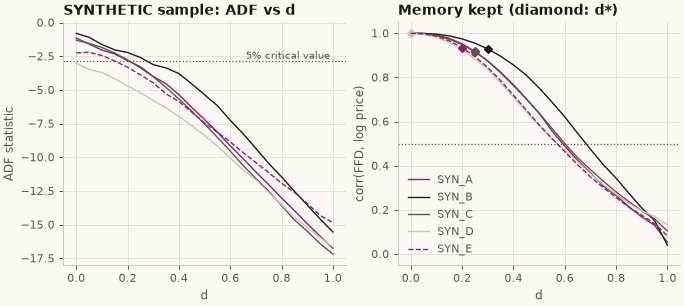

In [7]:
def draw(fig, c):
    left, right = fig.subplots(1, 2)
    palette = [c["accent"], c["text"], c["muted"], c["rule"], c["accent"]]
    styles = ["-", "-", "-", "-", "--"]
    for i, sym in enumerate(SYMBOLS):
        t = sweeps.filter(pl.col("series") == sym)
        kw = dict(color=palette[i % 5], linestyle=styles[i % 5], linewidth=1.1, label=sym)
        left.plot(t["d"], t["adf"], **kw)
        right.plot(t["d"], t["corr"], **kw)
        ds = d_star(t)
        if ds is not None:
            right.plot([ds], t.filter(pl.col("d") == ds)["corr"], marker="D", markersize=5,
                       color=palette[i % 5], linestyle="none")
    crit = float(sweeps["crit_5pct"].mean())
    left.axhline(crit, color=c["muted"], linestyle=":", linewidth=1.0)
    left.text(1.0, crit, "5% critical value ", ha="right", va="bottom", color=c["muted"], fontsize=8)
    left.set_xlabel("d")
    left.set_ylabel("ADF statistic")
    left.set_title(f"{LABEL} sample: ADF vs d")
    right.axhline(MIN_MEMORY, color=c["muted"], linestyle=":", linewidth=1.0)
    right.set_xlabel("d")
    right.set_ylabel("corr(FFD, log price)")
    right.set_ylim(-0.05, 1.05)
    right.set_title("Memory kept (diamond: d*)")
    right.legend(loc="lower left")


nbfigures.figure(
    "nb09-adf-corr-sample",
    draw,
    size=(7.6, 3.4),
    alt="ADF statistic and correlation with the log price against d for each synthetic sample symbol, with the 5% critical value and the 0.5 memory bar; each symbol's d* is marked.",
)

### Controls: does the sweep recover the known d*?

For each $\delta$: the distribution of $d^*$ over 200 paths, against the theoretical
$\max(0, \delta-0.5)$. `below_theory` is the share of paths whose $d^*$ is smaller than theory,
that is, paths where the procedure calls a series stationary that is not. The last two columns
repeat the study with five lagged differences in the ADF regression instead of one (sensitivity
only; the main result uses Snippet 5.4's single lag).

In [8]:
def per_path(lags: int) -> pl.DataFrame:
    t = control_sweeps.filter(pl.col("lags") == lags)
    first = (
        t.filter(pl.col("stationary"))
        .group_by("delta", "rep")
        .agg(pl.col("d").min().alias("d*"))
    )
    corr = t.select("delta", "rep", "d", "corr").rename({"d": "d*", "corr": "corr_at_d*"})
    return first.join(corr, on=["delta", "rep", "d*"], how="left")


def control_table() -> pl.DataFrame:
    main, sens = per_path(ADF_LAGS), per_path(SENS_LAGS)
    rows = []
    for delta in DELTAS:
        theory = max(0.0, round(delta - 0.5, 2))
        m = main.filter(pl.col("delta") == delta)
        s = sens.filter(pl.col("delta") == delta)
        rows.append(
            {
                "delta": delta,
                "theory_d*": theory,
                "paths_with_d*": m.height,
                "median_d*": float(m["d*"].median()),
                "p10_d*": float(m["d*"].quantile(0.1, "lower")),
                "p90_d*": float(m["d*"].quantile(0.9, "higher")),
                "below_theory": float((m["d*"] < theory - 1e-9).mean()),
                "median_corr_at_d*": float(m["corr_at_d*"].median()),
                "median_d*_5lags": float(s["d*"].median()),
                "below_theory_5lags": float((s["d*"] < theory - 1e-9).mean()),
            }
        )
    return pl.DataFrame(rows)


main_paths = per_path(ADF_LAGS)
controls_summary = control_table()
with pl.Config(tbl_rows=20, float_precision=3, tbl_width_chars=200, tbl_cols=20):
    print(controls_summary)

shape: (3, 10)
┌───────┬───────────┬───────────────┬───────────┬────────┬────────┬──────────────┬───────────────────┬─────────────────┬────────────────────┐
│ delta ┆ theory_d* ┆ paths_with_d* ┆ median_d* ┆ p10_d* ┆ p90_d* ┆ below_theory ┆ median_corr_at_d* ┆ median_d*_5lags ┆ below_theory_5lags │
│ ---   ┆ ---       ┆ ---           ┆ ---       ┆ ---    ┆ ---    ┆ ---          ┆ ---               ┆ ---             ┆ ---                │
│ f64   ┆ f64       ┆ i64           ┆ f64       ┆ f64    ┆ f64    ┆ f64          ┆ f64               ┆ f64             ┆ f64                │
╞═══════╪═══════════╪═══════════════╪═══════════╪════════╪════════╪══════════════╪═══════════════════╪═════════════════╪════════════════════╡
│ 0.400 ┆ 0.000     ┆ 200           ┆ 0.000     ┆ 0.000  ┆ 0.000  ┆ 0.000        ┆ 1.000             ┆ 0.000           ┆ 0.000              │
│ 0.700 ┆ 0.200     ┆ 200           ┆ 0.000     ┆ 0.000  ┆ 0.000  ┆ 1.000        ┆ 1.000             ┆ 0.000           ┆ 0.925       

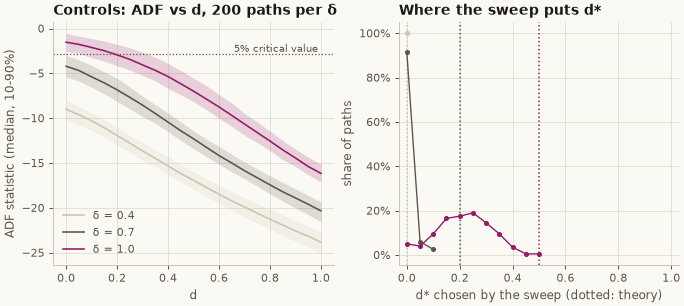

In [9]:
def draw(fig, c):
    left, right = fig.subplots(1, 2)
    t = control_sweeps.filter(pl.col("lags") == ADF_LAGS)
    for delta, col in zip(DELTAS, [c["rule"], c["muted"], c["accent"]]):
        g = t.filter(pl.col("delta") == delta).group_by("d").agg(
            pl.col("adf").median().alias("med"),
            pl.col("adf").quantile(0.1).alias("lo"),
            pl.col("adf").quantile(0.9).alias("hi"),
        ).sort("d")
        left.fill_between(g["d"], g["lo"], g["hi"], color=col, alpha=0.18, linewidth=0)
        left.plot(g["d"], g["med"], color=col, linewidth=1.3, label=f"δ = {delta}")
        theory = max(0.0, delta - 0.5)
        counts = main_paths.filter(pl.col("delta") == delta)["d*"].value_counts().sort("d*")
        right.plot(counts["d*"], counts["count"] / N_REPS, color=col, marker="o", markersize=3,
                   linewidth=1.1, label=f"δ = {delta}")
        right.axvline(theory, color=col, linestyle=":", linewidth=1.2)
    crit = float(t["crit_5pct"].mean())
    left.axhline(crit, color=c["muted"], linestyle=":", linewidth=1.0)
    left.text(1.0, crit, "5% critical value ", ha="right", va="bottom", color=c["muted"], fontsize=8)
    left.set_xlabel("d")
    left.set_ylabel("ADF statistic (median, 10-90%)")
    left.set_title(f"Controls: ADF vs d, {N_REPS} paths per δ")
    left.legend(loc="lower left")
    right.set_xlabel("d* chosen by the sweep (dotted: theory)")
    right.set_ylabel("share of paths")
    right.yaxis.set_major_formatter(nbfigures.percent)
    right.set_xlim(-0.03, 1.03)
    right.set_title("Where the sweep puts d*")


nbfigures.figure(
    "nb09-controls",
    draw,
    size=(7.6, 3.4),
    alt="Left: median ADF statistic against d for simulated series of integration order 0.4, 0.7 and 1.0, with 10 to 90 percent bands. Right: distribution of the chosen d* for each order, with the theoretical value dotted; every distribution sits to the left of its theoretical value except for order 0.4.",
)

### What integer differencing throws away

Memory kept at $d^*$ against memory kept by log returns ($d=1$), per sample symbol.

shape: (5, 5)
┌────────┬───────┬────────────┬───────────────────────┬──────────────────────────┐
│ symbol ┆ d*    ┆ corr at d* ┆ corr at d=1 (returns) ┆ memory kept over returns │
│ ---    ┆ ---   ┆ ---        ┆ ---                   ┆ ---                      │
│ str    ┆ f64   ┆ f64        ┆ f64                   ┆ f64                      │
╞════════╪═══════╪════════════╪═══════════════════════╪══════════════════════════╡
│ SYN_A  ┆ 0.250 ┆ 0.918      ┆ 0.053                 ┆ 0.865                    │
│ SYN_B  ┆ 0.300 ┆ 0.929      ┆ 0.040                 ┆ 0.889                    │
│ SYN_C  ┆ 0.250 ┆ 0.916      ┆ 0.104                 ┆ 0.812                    │
│ SYN_D  ┆ 0.000 ┆ 1.000      ┆ 0.131                 ┆ 0.869                    │
│ SYN_E  ┆ 0.200 ┆ 0.935      ┆ 0.082                 ┆ 0.853                    │
└────────┴───────┴────────────┴───────────────────────┴──────────────────────────┘


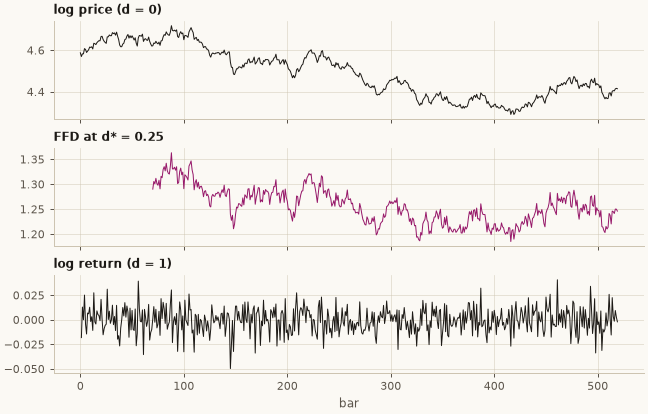

In [10]:
memory = results.select(
    "symbol",
    "d*",
    pl.col("corr_at_d*").alias("corr at d*"),
    pl.col("corr_at_d=1").alias("corr at d=1 (returns)"),
    (pl.col("corr_at_d*") - pl.col("corr_at_d=1")).alias("memory kept over returns"),
)
with pl.Config(tbl_rows=20, float_precision=3):
    print(memory)

example = SYMBOLS[0]
ds_example = results.filter(pl.col("symbol") == example)["d*"][0]


def draw(fig, c):
    x = log_close[example]
    panels = [(0.0, "log price (d = 0)")]
    if ds_example is not None and 0 < ds_example < 1:
        panels.append((ds_example, f"FFD at d* = {ds_example:.2f}"))
    panels.append((1.0, "log return (d = 1)"))
    axes = fig.subplots(len(panels), 1, sharex=True)
    for ax, (d, label) in zip(axes, panels):
        ax.plot(ffd(x, d), color=c["accent"] if 0 < d < 1 else c["text"], linewidth=0.8)
        ax.set_title(label, fontsize=9.5)
    axes[-1].set_xlabel("bar")


nbfigures.figure(
    "nb09-series-at-dstar",
    draw,
    size=(7.2, 4.6),
    alt="Stacked panels for the first sample symbol: the log price, the FFD series at d*, and the log returns.",
)

### Stability: choose d* on the first half, test it on the second

The same sweep on the first half of each sample series picks $d^*_{\text{train}}$; the second half
is then FFD-differenced at that $d^*_{\text{train}}$ (the window uses only second-half bars) and
tested once. `d*_test_half` is what a sweep on the second half alone would have chosen.

In [11]:
rows = []
for sym, x in log_close.items():
    half = len(x) // 2
    ds_train = d_star(sweep(sym, x[:half]))
    test = {"test_adf": None, "test_crit": None, "test_stationary": None, "test_corr": None}
    if ds_train is not None:
        out = ffd(x[half:], ds_train)
        ok = ~np.isnan(out)
        stat, crit, _ = adf(out[ok])
        corr = float(np.corrcoef(out[ok], x[half:][ok])[0, 1]) if ds_train > 0 else 1.0
        test = {"test_adf": stat, "test_crit": crit, "test_stationary": stat < crit, "test_corr": corr}
    rows.append(
        {
            "symbol": sym,
            "d*_full": results.filter(pl.col("symbol") == sym)["d*"][0],
            "d*_train": ds_train,
            "d*_test_half": d_star(sweep(sym, x[half:])),
            **test,
        }
    )
stability = pl.DataFrame(rows)
with pl.Config(tbl_rows=20, float_precision=3, tbl_width_chars=200, tbl_cols=20):
    print(stability)

shape: (5, 8)
┌────────┬─────────┬──────────┬──────────────┬──────────┬───────────┬─────────────────┬───────────┐
│ symbol ┆ d*_full ┆ d*_train ┆ d*_test_half ┆ test_adf ┆ test_crit ┆ test_stationary ┆ test_corr │
│ ---    ┆ ---     ┆ ---      ┆ ---          ┆ ---      ┆ ---       ┆ ---             ┆ ---       │
│ str    ┆ f64     ┆ f64      ┆ f64          ┆ f64      ┆ f64       ┆ bool            ┆ f64       │
╞════════╪═════════╪══════════╪══════════════╪══════════╪═══════════╪═════════════════╪═══════════╡
│ SYN_A  ┆ 0.250   ┆ 0.250    ┆ 0.250        ┆ -3.207   ┆ -2.877    ┆ true            ┆ 0.889     │
│ SYN_B  ┆ 0.300   ┆ 0.300    ┆ 0.050        ┆ -3.307   ┆ -2.877    ┆ true            ┆ 0.790     │
│ SYN_C  ┆ 0.250   ┆ 0.300    ┆ 0.250        ┆ -3.432   ┆ -2.877    ┆ true            ┆ 0.872     │
│ SYN_D  ┆ 0.000   ┆ 0.150    ┆ 0.200        ┆ -2.567   ┆ -2.877    ┆ false           ┆ 0.949     │
│ SYN_E  ┆ 0.200   ┆ 0.250    ┆ 0.050        ┆ -3.863   ┆ -2.877    ┆ true            

### Look-ahead check (shift test)

FFD must use only current and past bars. Replace every bar after an index `t0` with noise: every
FFD output at or before `t0` must be unchanged, for every $d$ on the grid. A single future value
leaking into a weight would break this.

In [12]:
x = log_close[SYMBOLS[0]]
t0 = len(x) // 2
shocked = x.copy()
shocked[t0 + 1 :] = np.random.default_rng(SEED + 1).normal(0.0, 1.0, len(x) - t0 - 1)
leaks = sum(
    not np.array_equal(ffd(x, d)[: t0 + 1], ffd(shocked, d)[: t0 + 1], equal_nan=True) for d in D_GRID
)
print(f"d values whose FFD output up to t0 changed when the future changed: {leaks} of {len(D_GRID)}")
assert leaks == 0

d values whose FFD output up to t0 changed when the future changed: 0 of 21


## Analysis

In [13]:
print(f"sample symbols supporting H1: {int(results['H1'].sum())} of {results.height}")
print(f"sample d*: {results['d*'].to_list()}")
print("sample corr at d*:", [round(v, 3) for v in results["corr_at_d*"].to_list()])
print("sample weight_sum at d*:", [round(v, 3) for v in results["weight_sum_at_d*"].to_list()])
print(
    "train-half d* passes on the test half:",
    f"{int(stability['test_stationary'].fill_null(False).sum())} of {stability.height}",
)
for row in controls_summary.iter_rows(named=True):
    print(
        f"controls delta={row['delta']}: theory d*={row['theory_d*']}, median d*={row['median_d*']},"
        f" below theory on {row['below_theory']:.0%} of paths ({row['below_theory_5lags']:.0%} with 5 lags)"
    )

sample symbols supporting H1: 5 of 5
sample d*: [0.25, 0.3, 0.25, 0.0, 0.2]
sample corr at d*: [0.918, 0.929, 0.916, 1.0, 0.935]
sample weight_sum at d*: [0.282, 0.22, 0.282, 1.0, 0.365]
train-half d* passes on the test half: 4 of 5
controls delta=0.4: theory d*=0.0, median d*=0.0, below theory on 0% of paths (0% with 5 lags)
controls delta=0.7: theory d*=0.2, median d*=0.0, below theory on 100% of paths (92% with 5 lags)
controls delta=1.0: theory d*=0.5, median d*=0.2, below theory on 100% of paths (88% with 5 lags)


The committed numbers come from SYNTHETIC data. They describe the procedure, not a market.

1. **H1 as pre-registered is supported on all five sample symbols.** The sweep finds $d^*$ between
   0.20 and 0.30 for `SYN_A`, `SYN_B`, `SYN_C` and `SYN_E`, where the FFD series still correlates
   0.92 to 0.94 with the log price. Log returns ($d=1$) keep 0.04 to 0.13. `SYN_D` rejects a unit
   root at $d=0$: its level already passes the test, which for a random walk is a 5% false
   rejection (one symbol in five is in line with that). The curves have the shape of AFML Fig. 5.5.
2. **The controls show what that result is worth.** Every `SYN_*` symbol is a random walk
   ($\delta=1$). Theory says its fractional difference is stationary only for $d>0.5$, yet the sweep
   stops at 0.20-0.30. The 200 simulated random walks behave the same way: median $d^*$ 0.20, and
   $d^*$ below the theoretical 0.5 on 199 of 200 paths. At $\delta=0.7$ the sweep picks $d=0$ (no
   differencing) on about nine paths in ten, although theory needs $d>0.2$. The procedure recovers
   the right answer only where the answer is trivially $d^*=0$ ($\delta=0.4$). Five lagged
   differences instead of one move the medians only a little (to 0.30 for $\delta=1$), so the lag
   choice is not the cause.
3. **Why: ADF has the wrong null for this question.** ADF tests *a unit root* against
   stationarity. A series integrated of order $\delta-d$ between 0.5 and 1 has no unit root, so
   ADF correctly rejects, but the series is still not stationary. "The smallest $d$ that passes ADF"
   finds where the series stops being a unit-root process, not where it becomes stationary, and in
   finite samples that point sits well below the stationarity boundary.
4. **The high correlation is partly an undifferenced level.** With `thresh = 1e-3` the truncated
   FFD weights at $d^*$ sum to 0.22-0.37 instead of 0 (the `weight_sum` column). A fifth to a third
   of the log price passes straight through the filter, which inflates the correlation with the
   price and leaves a trending component in the output (visible in the FFD panel of the series
   figure). A smaller threshold drives the sum toward 0, at the cost of a much longer window at low
   $d$ (at $d=0.1$: 62 bars at `1e-3`, about 500 at `1e-4`, nearly all of this two-year sample).
5. **$d^*$ is not stable across halves.** Chosen on the first half, $d^*$ still passes ADF on the
   second half for four of five symbols; `SYN_D` fails. A sweep on the second half alone moves $d^*$
   for three of five symbols compared with the full sample: `SYN_B` 0.30 to 0.05, `SYN_E` 0.20 to
   0.05, `SYN_D` 0.00 to 0.20.
   On series built by the same process, that spread is sampling noise, and it is as large as the
   values being estimated.
6. **No look-ahead.** The shift test finds no FFD output that depends on a later bar.

## Promotion decision

**Decision: do not promote.** Later runbooks should not use "per-symbol $d^*$ = the smallest $d$
passing ADF at 5%" as their default feature transform.

H1 passes as it was written, 5 of 5, but the controls with known memory show that passing it does
not mean stationarity. On random walks the rule picks $d \approx 0.2$-$0.3$, where theory needs
more than 0.5, on 199 of 200 paths. The retained memory is inflated by truncated weights that pass
a fifth to a third of the level through, and the selected $d^*$ moves as much between the halves
of the sample as it varies between symbols. A feature built this way would be less stationary
than the procedure says, and its apparent memory would partly be the price level.

What later runbooks should do instead:

- Keep `frac_diff_ffd` as a **candidate** feature, with $d$ chosen on the training span only and
  reported as a hyperparameter that counts toward the trial total.
- If $d$ is chosen by a test, pair ADF with a test whose null is stationarity (KPSS or similar),
  or use an estimate of the memory parameter, not the first ADF rejection.
- Report the sum of the truncated FFD weights next to any FFD feature, and lower `thresh` until it
  is near 0 when the history allows.
- Settle whether FFD features add predictive value (issue #49's classifier leg) on real data or on
  a synthetic series with a planted signal, in purged CV and net of costs. This runbook does not
  test that.

The decision describes the **procedure**, established on synthetic series whose memory is known.
It says nothing about the $d^*$ of any real instrument. Run the notebook on your own data (see the
top cell) and read the controls table next to your own $d^*$ table.

## Self-review checklist

- [x] **No look-ahead in the transform.** FFD applies fixed weights to the current and past bars
  only; the shift test replaces every future bar and finds no change in any earlier output, for all
  21 values of $d$.
- [x] **In-sample selection is flagged.** The headline $d^*$ is chosen on each symbol's full
  sample and labelled in-sample. The stability table re-chooses it on the first half and tests it
  on the second.
- [x] **Trial count recorded.** On the data: 21 values of $d$ x 5 symbols = 105 (symbol, $d$)
  evaluations for the headline, plus 2 x 105 for the half-sample re-sweeps. On simulations:
  3 $\delta$ x 200 paths x 21 $d$ x 2 lag settings = 25,200 evaluations, which describe the method
  and select nothing. `FFD_THRESH`, `ADF_LAGS`, `ALPHA` and `MIN_MEMORY` were fixed before the
  first run and not varied; the 5-lag ADF is a declared sensitivity on the controls only. One
  earlier run used a single control path per $\delta$ (see Data); it is disclosed there and changed
  no parameter. `openquant.evaluation` (the trial registry, #139) is not on this base, so the count
  is recorded here and in the run manifest below. No strategy returns are computed, so there is no
  Sharpe ratio to deflate.
- [x] **Data labelled.** Tables, printouts and figure titles say SYNTHETIC when the default source
  is used; the controls are simulated in this notebook from a stated seed and hashed.
- [x] **ADF implementation checked.** Matches `statsmodels.tsa.stattools.adfuller(maxlag=1,
  regression="c", autolag=None)` (statistic and 5% critical value) to 1e-12 on test series.
  `statsmodels` is not a dependency, so the comparison is not repeated in CI.
- [ ] **Not covered here.** Issue #49 also asks whether FFD features beat plain returns in a
  purged-CV classifier, net of a cost model. On random-walk data no feature can predict returns, so
  that comparison would only measure noise; it needs real data or a synthetic series with a planted
  signal, and is left to a follow-up runbook.

## Reproducibility

In [14]:
import nbrepro

manifest = openquant.research.research_run_manifest(
    {
        "notebook": "09_fracdiff_stationarity_memory",
        "symbols": SYMBOLS,
        "d_grid": D_GRID,
        "ffd_thresh": FFD_THRESH,
        "adf": {"regression": "c", "lags": ADF_LAGS, "alpha": ALPHA, "crit": "MacKinnon 2010"},
        "min_memory": MIN_MEMORY,
        "controls": {"deltas": DELTAS, "reps": N_REPS, "n": N_CONTROL, "sens_lags": SENS_LAGS},
        "seed": SEED,
        "trials": {"data": TRIALS, "data_half_samples": 2 * TRIALS, "simulated": SIM_EVALS},
    }
)
openquant.data.record_dataset_hash(
    manifest,
    digest=meta["dataset_hash"],
    **{k: meta[k] for k in ("source", "symbols", "start", "end", "rows")},
)
manifest["controls_hash"] = controls_hash

nbrepro.footer(
    seed=SEED,
    data_hash=manifest["dataset_hash"],
    data=LABEL,
    trials=manifest["config"]["trials"],
    config=manifest["config"],
    stderr={"controls": controls_hash},  # platform-dependent, see Data
)

data hash:    sha256:b311c219efb2a19db449767cc8600139c030aad15496b011fc650b4880550eea
seed:         49
config:       2c5b18df7c03
data:         SYNTHETIC
trials:       {'data': 105, 'data_half_samples': 210, 'simulated': 25200}


controls:     sha256:e7c5f3a944e21bab352c8c434957c9491ca7f60ca8538a9b155816f262afe34f
git sha:      the commit containing this notebook (CI re-runs it there)
package:      pyopenquant built from that commit; dependencies from its uv.lock
